## Compute a global time slice map for a chosen statistic over a given time period

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

import xesmf as xe


Loading packages...


## 0) define functions

In [2]:
def calc_vertical_stat(da, thickness_weights, stat, mask=None, dims=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_vertical_mean(da, thickness_weights, mask=mask, dims=dims)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_vertical_integral(da, thickness_weights, mask=mask, dims=dims)
    return da_stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat

In [3]:
#server = 'spirit'

from dask.distributed import Client
client = Client(n_workers=8)
client

server = MISCgrabber.get_server()
if server == 'levante':
    port = client.scheduler_info()["services"]["dashboard"]
    prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "/")
    proxy_url = f"https://jupyterhub.dkrz.de/{prefix}proxy/{port}/status"
    print(proxy_url)

working on server spirit


## 1) get the varias, models and runs over which to do the computation

In [5]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['tas','tos','fgco2','nbp','intpp','npp','cLand','cVeg','cSoil','intdic'] #['tas','tos','fgco2','nbp','intpp','npp','cLand','cVeg','cSoil','intdic']#['dissic']#['tos','fgco2','intpp','intdic','tas','cLand','cSoil','cVeg','npp','nbp']#['intdic']#['dissic']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #[,'tas'] #['intdic']#['cLand','cSoil','cVeg','tos','nbp','fgco2','npp','intpp','tas']#'dissic'] #['tas']#['dissic']##['cVeg']#'tas','tos', #['tas','tos', #'tas', #['npp']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['ACCESS-ESM1-5']#['GISSE2.1-G-CC2']#['CESM2']#['MIROC-ES2L']#['UKESM1-2']#['EC-Earth3-ESM-1']#['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['NorESM2-LM']# ['GISSE2.1-G-CC2']#['ACCESS-ESM1-5']
runs = pruns.get_run_list('tipmip_tier1')#[1:]#:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

# choose the type of temporal statisic
temporal_stats = ['mean']#,'linear_trend'] # ['mean']#['linear_trend'] # 'mean', 'std', 'linear trend', 
# choose the time window length (in years) for rolling_mean
rm_window = 31 # in years
# choose the time_window_size for tim slices
time_window_size = 21 # in years
# choose the reference 
#reference = 'first_year_of_rampup' # 'first_year_of_piC', 'first_10y_of_rampup', ...
# choose GMST levels at which to calculate time slice maps (for rampup and rampdown). For the piC, and stabilizations, I calculate the time slice statistic over the first time_window_size years
#gmst_levels = [0,1,2,3,4]

#server='spirit' # 'cineca'#
outroot = './../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/'

# Define zec time horizons
ZECs = [0,10,25,50,100,150,200]#,250,300]

# Define the runs_to_analyse
run_names = ['esm-piControl',
             #'esm-up2p0-gwl2p0',
             #'esm-up2p0-gwl4p0',
             #'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'
            ]


def get_time_range_underlying_time_slice(model,run_name,zec_horizon,time_window_size,temporal_stat):    #,running_mean_years=31,centered_running_mean=True,reference_slice='jones2025'):

    # get the model_dict for extra info
    model_dict = pmods.get_model_dict('all')

    
    if temporal_stat == 'mean':
    
        # half_window
        half_window = int((time_window_size-1)/2)
        if zec_horizon == 0:
            half_window = 0 
        
        if run_name == 'esm-piControl':
            if model == 'ACCESS-ESM1-5':
                time_slice_start_year = 271 #model_dict[model].rampup_start_year
                time_slice_end_year = 271+time_window_size-1 #model_dict[model].rampup_start_year+time_window_size-1 
            else:
                time_slice_start_year = model_dict[model].rampup_start_year + zec_horizon - half_window
                time_slice_end_year = model_dict[model].rampup_start_year + zec_horizon + half_window
        elif run_name == 'esm-up2p0-gwl2p0':
            time_slice_start_year = model_dict[model].stab2K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].stab2K_start_year + zec_horizon + half_window #  last (time_window_size)years of the stabilization before rampdown
        elif run_name == 'esm-up2p0-gwl4p0':
            time_slice_start_year = model_dict[model].stab4K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].stab4K_start_year + zec_horizon + half_window  #  last (time_window_size)years of the stabilization before rampdown
        elif run_name == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
            time_slice_start_year = model_dict[model].restab2K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].restab2K_start_year + zec_horizon + half_window   #  last (time_window_size)years of the restabilization
    
        # turn nan years into None
        print(time_slice_start_year)
        print(time_slice_end_year)
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
        print(time_slice_start_year)
        print(time_slice_end_year)

    elif temporal_stat == 'linear_trend':

        if run_name == 'esm-piControl':
            if model == 'ACCESS-ESM1-5':
                time_slice_start_year = 271 #model_dict[model].rampup_start_year
                time_slice_end_year = 271+zec_horizon #model_dict[model].rampup_start_year+time_window_size-1 
            else:
                time_slice_start_year = model_dict[model].rampup_start_year
                time_slice_end_year = model_dict[model].rampup_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl2p0':
            time_slice_start_year = model_dict[model].stab2K_start_year
            time_slice_end_year = model_dict[model].stab2K_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl4p0':
            time_slice_start_year = model_dict[model].stab4K_start_year
            time_slice_end_year = model_dict[model].stab4K_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
            time_slice_start_year = model_dict[model].restab2K_start_year
            time_slice_end_year = model_dict[model].restab2K_start_year + zec_horizon - 1

        # turn nan years into None
        print(time_slice_start_year)
        print(time_slice_end_year)
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
        if time_slice_end_year == time_slice_start_year - 1:
            time_slice_end_year = time_slice_start_year
        print(time_slice_start_year)
        print(time_slice_end_year)
    
    return time_slice_start_year, time_slice_end_year


def calc_time_slice_stat(varia,model,run,ZEC,time_slice_start_year,time_slice_end_year,temporal_stat='mean',vert_stat=None):

    if model == 'CESM2':
        print(varia)
        varia = mgrab.varia_mapper_cmor_to_model(varia)
        print(varia)
                
    # first get the dataset
    da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=0)#,server=server)#,server=server)
    print(f'... loading {da.time.size} data points in time.')

    if model == 'CESM2' and varia == 'TEMP':
        print('choosing only the shallowest layer')
        da = da.isel(z_t=0)#.squeeze().persist()
        print(da)

    # make sure the time dimension is Proleptic Gregorian
    da = TimeOperator.shift_time_axis_by_n_years(da,n=0)
    
    # get unit
    unit = da.units

    # =====================================================
    # OPTIONAL VERTICAL STAT
    # =====================================================
    if vert_stat is not None:
        domain = mgrab.get_domain(varia,freq_input)
        print(domain)
        print(da.dims)
        if domain in ['O','OP','OB','ocn']:
            if "lev" in da.dims:
                da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
            elif "olevel" in da.dims:
                da = da.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
            elif "z_t" in da.dims:
                da = da.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})

            print('... get thickness weights')
            if model == 'NorESM2-LM':
                thickness_weights = mgrab.get_thickness(
                    'thkcello',freq_input)
                thickness_weights = thickness_weights.chunk({"lev": -1})#,"i": -1,"j": -1})
            elif model == 'GFDL-ESM2M':
                thickness_weights = mgrab.get_data(
                    'thkcello',run,freq_input=freq_input, verbose_level=0)
                thickness_weights = thickness_weights.chunk({"time": 12, "olevel": -1})#,"i": -1,"j": -1})
                thickness_weights = TimeOperator.shift_time_axis_by_n_years(thickness_weights,n=0)
            elif model == 'CESM2':
                thickness_weights = mgrab.get_dz(run,freq_input='monthly',verbose_level=1)
            else:
                thickness_weights = mgrab.get_data(
                    'thkcello', run, freq_input=freq_input, verbose_level=0)
                thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
            #print(thickness_weights)
        elif domain in ['A']:
            da = da.chunk({"time": 12,"plev": -1})#,"i": -1,"j": -1})
            plev = da["plev"]  # [plev], in Pa
            # Step 1: layer thickness from differences
            dp = np.abs(plev.diff(dim="plev"))
            # Step 2: append last value (reuse last plev)
            last_plev = plev.isel(plev=-1)
            dp = xr.concat([dp, last_plev], dim="plev")
            # Step 3: fix coordinate alignment
            thickness_weights = dp.assign_coords(plev=plev)

        
        print('... compute vertical statistic')
        print(da)
        print(thickness_weights)
        da_for_horiz = calc_vertical_stat(
            da,
            thickness_weights,
            vert_stat,
            mask=None,
            dims=None,
        )
        print(da_for_horiz)
        da_for_horiz.name = f"{varia}_vertical_{vert_stat}"
        da_for_horiz = da_for_horiz.persist()
        da = da_for_horiz
    #else:
    #    da_for_horiz = da

    #print(da)
    
    # resample to annual means
    da_annual = da.resample(time='1YS').mean(dim='time') # weight with month lengths?
    #print(da_annual.time)

    # cut out the time slice
    #da_annual_slice = da_annual.sel(time=slice(cftime.DatetimeProlepticGregorian(time_slice_start_year,1,1),cftime.DatetimeProlepticGregorian(time_slice_end_year,1,1)))

    if time_slice_start_year is None or time_slice_end_year is None:
    
        da_annual_slice = xr.full_like(
            da_annual.isel(time=slice(0, 2)).astype(float),
            np.nan,
        )

    elif time_slice_start_year == time_slice_end_year and temporal_stat == 'linear_trend':
        da_annual_slice = xr.full_like(
            da_annual.isel(time=slice(0, 2)).astype(float),
            np.nan,
        )        
    
    else:
        da_annual_slice = da_annual.sel(
            time=slice(
                cftime.DatetimeProlepticGregorian(time_slice_start_year, 1, 1),
                cftime.DatetimeProlepticGregorian(time_slice_end_year, 1, 1),
            )
        )

    
    # If the variable is npp or nbp, weight with the land area fraction
    grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on

    # take into account that coastal cells are not 100% land
    if grid_cell_fractions is not None:
        print('adjust area weights for coastal points')
        assert np.max(grid_cell_fractions.values)<=1
        assert np.min(grid_cell_fractions.values)>=0
        # make sure that the coordinates area the same
        for coord in da_annual_slice.coords:
            if coord == 'time':
                continue
            diff_coord = grid_cell_fractions[coord].values - da_annual_slice[coord].values
            sum_diff_coord = np.sum(np.abs(diff_coord))
            unique_diffs = np.unique(diff_coord)
            if sum_diff_coord > 0:
                print(f'There is a total coordinate difference of: {sum_diff_coord}')
                if np.sum(np.abs((grid_cell_fractions[coord].values - da_annual_slice[coord].values))) < 1e-1:
                    print(f'... this is small enough (smaller than 1e-1), so we just set the grid_cell_fractions.coord to area_weights.coord.')
                    grid_cell_fractions = grid_cell_fractions.assign_coords({coord: da_annual_slice[coord]})
                elif np.all(np.isin(unique_diffs, [-360, 0, 360])):
                    print(f'... all of the differences are just caused by 360° longitude wrapping. So we just set the grid_cell_fractions.coord to area_weights.coord.')
                    grid_cell_fractions = grid_cell_fractions.assign_coords({coord: da_annual_slice[coord]})        
                else:
                    raise Exception('Coordinates do not match')
        # now multiply them together
        da_annual_slice = da_annual_slice * grid_cell_fractions.values
        multiplied_with_area_fraction = True
    else:
        multiplied_with_area_fraction = False

    if temporal_stat == 'mean':
        temp_statistic = da_annual_slice.mean(dim='time')
        unit = unit
    elif temporal_stat == 'linear_trend':
        #da_annual_part = da_annual.sel(time=slice(None,ZEC))
        decimal_year = xr.DataArray(da_annual_slice.time.dt.year,dims="time")
        print(np.size(decimal_year))
        # Assign numeric coordinate
        da_annual_slice = da_annual_slice.assign_coords(decimal_year=decimal_year)
        # Fit trend
        coeff = da_annual_slice.swap_dims({"time": "decimal_year"}).polyfit(dim="decimal_year",deg=1)
        temp_statistic = coeff.polyfit_coefficients.sel(degree=1).squeeze()
        temp_statistic = temp_statistic.drop_vars('degree')
        unit = f'{unit} yr-1'
        print(da_annual_slice)
        if 'latitude' in da_annual_slice.coords:
            temp_statistic = temp_statistic.assign_coords({
                "lat": da_annual_slice.latitude,
                "lon": da_annual_slice.longitude,
            })
    else:
        raise Exception('This temporal_stat is not yet defined.')
    
    return temp_statistic, unit, multiplied_with_area_fraction


def regrid_field(ds,tmp_in,tmp_out,method='xesmf'):

    #print(ds)

    if method == 'cdo':
        subprocess.run(["cdo", "remapdis,r360x180", tmp_in, tmp_out],check=True)
        ds_out = xr.open_dataset(tmp_out)
        ds_out.attrs.update(global_attrs)
        ds_out.to_netcdf(tmp_out+'2', mode="w")
        subprocess.run(["mv", tmp_out+'2', tmp_out], check=True)
        return print('done with cdo')

    elif method == 'xesmf':

        #print('REGRIDDING')
        #print(ds)

        # Make a copy to avoid modifying original dataset
        ds_copy = ds.copy()

        
        ## Case 1: 2D lat/lon coordinates exist
        if "geolat_t" in ds_copy.coords and "geolon_t" in ds_copy.coords:
            print("geolat_t/geolon_t present")
            
            ds_copy = ds_copy.set_coords(["geolat_t", "geolon_t"])
            ds_copy = ds_copy.rename({"geolat_t": "lat", "geolon_t": "lon"})
            # Load into memory if dask arrays
            ds_copy["lat"] = ds_copy["lat"].load()
            ds_copy["lon"] = ds_copy["lon"].load()
            # Optional: add CF attributes
            ds_copy["lat"].attrs.update({
                "standard_name": "latitude",
                "long_name": "Latitude of T points",
                "units": "degrees_north"
            })
            ds_copy["lon"].attrs.update({
                "standard_name": "longitude",
                "long_name": "Longitude of T points",
                "units": "degrees_east"
            })
    
        # Target grid: r360x180
        target = xr.Dataset({
            "lat": (["lat"], np.linspace(-89.5, 89.5, 180)),
            "lon": (["lon"], np.linspace(-179.5, 179.5, 360)),
        })
    
        # Create the regridder
        regridder = xe.Regridder(ds_copy, target, method="nearest_s2d", periodic=True)
    
        # Regrid the dataset
        ds_regridded = regridder(ds_copy)
    
        # Update global attributes and save
        #ds_regridded.attrs.update(global_attrs)

        #print('SAVING')
        #ds_regridded.to_netcdf(tmp_out)
        print('        ... done with xesmf')

    return ds_regridded # 


def regrid_field(ds, tmp_in, tmp_out, method='xesmf'):

    import xarray as xr
    import numpy as np
    import xesmf as xe
    import subprocess

    # ==========================================================
    # CDO METHOD
    # ==========================================================
    if method == 'cdo':

        subprocess.run(
            ["cdo", "remapdis,r360x180", tmp_in, tmp_out],
            check=True
        )

        ds_out = xr.open_dataset(tmp_out)

        # Optional global attrs
        # ds_out.attrs.update(global_attrs)

        ds_out.to_netcdf(tmp_out + '2', mode="w")

        subprocess.run(
            ["mv", tmp_out + '2', tmp_out],
            check=True
        )

        print('done with cdo')

        return ds_out

    # ==========================================================
    # XESMF METHOD
    # ==========================================================
    elif method == 'xesmf':

        # ------------------------------------------
        # Handle both DataArray and Dataset inputs
        # ------------------------------------------
        input_is_dataarray = isinstance(ds, xr.DataArray)

        if input_is_dataarray:
            varname = ds.name or "var"
            ds_copy = ds.to_dataset(name=varname)
        else:
            ds_copy = ds.copy()

        # handling CESM2 model
        drop_vars = [v for v in ["ULONG", "ULAT"]
                     if v in ds_copy.variables]

        
        ds_copy = ds_copy.drop_vars(drop_vars)

        # ------------------------------------------
        # Handle MOM-style curvilinear grids
        # ------------------------------------------
        if "geolat_t" in ds_copy.coords and "geolon_t" in ds_copy.coords:

            print("geolat_t/geolon_t present")

            ds_copy = ds_copy.set_coords(["geolat_t", "geolon_t"])

            ds_copy = ds_copy.rename({
                "geolat_t": "lat",
                "geolon_t": "lon"
            })

            # Ensure coordinates are loaded
            ds_copy["lat"] = ds_copy["lat"].load()
            ds_copy["lon"] = ds_copy["lon"].load()

            # Add CF-compliant attributes
            ds_copy["lat"].attrs.update({
                "standard_name": "latitude",
                "long_name": "Latitude",
                "units": "degrees_north"
            })

            ds_copy["lon"].attrs.update({
                "standard_name": "longitude",
                "long_name": "Longitude",
                "units": "degrees_east"
            })

        # ------------------------------------------
        # Target regular 1-degree grid
        # ------------------------------------------
        target = xr.Dataset({
            "lat": (
                ["lat"],
                np.linspace(-89.5, 89.5, 180)
            ),
            "lon": (
                ["lon"],
                np.linspace(-179.5, 179.5, 360)
            ),
        })

        # ------------------------------------------
        # Create regridder
        # ------------------------------------------
        regridder = xe.Regridder(
            ds_copy,
            target,
            method="nearest_s2d",
            periodic=True
        )

        # ------------------------------------------
        # Regrid
        # ------------------------------------------
        ds_regridded = regridder(ds_copy)

        # ------------------------------------------
        # Optional global attrs
        # ------------------------------------------
        # ds_regridded.attrs.update(global_attrs)

        # ------------------------------------------
        # Convert back to DataArray if needed
        # ------------------------------------------
        if input_is_dataarray:
            ds_regridded = ds_regridded[varname]

        print('        ... done with xesmf')

        return ds_regridded

In [6]:
for varia in varias:
    vert_stat = get_vert_stat(varia)

    for model in models:

        mgrab = MODELgrabber.get_grabber(model)

        print(f'---{model}---')

        temporal_stat_dict = {}

        for temporal_stat in temporal_stats:

            ds = xr.Dataset()

            # store bounds for all runs
            run_start_years = {}
            run_end_years = {}

            for run in run_names:

                print(f'--- run: {run} ---')
                member = mgrab.get_member()#run)

                
                statistic_regridded_all = []
                start_years = []
                end_years = []

                for ZEC in ZECs:

                    print(
                        f'-> calculate time slice statistic(s) for '
                        f'{varia}, {model}, {run}, {ZEC} year ZEC.'
                    )

                    time_slice_start_year, time_slice_end_year = (
                        get_time_range_underlying_time_slice(
                            model,
                            run,
                            ZEC,
                            time_window_size,
                            temporal_stat
                        )
                    )

                    print(
                        '... time range:',
                        time_slice_start_year,
                        time_slice_end_year
                    )

                    print(f'    ... computing {temporal_stat}')

                    statistic, unit, multiplied_with_area_fraction = (
                        calc_time_slice_stat(
                            varia,
                            model,
                            run,
                            ZEC,
                            time_slice_start_year,
                            time_slice_end_year,
                            temporal_stat=temporal_stat,
                            vert_stat=vert_stat
                        )
                    )

                    print(statistic)
                    print('    ... regridding')

                    tmp_in = "./in.nc"
                    tmp_out = "./out.nc"

                    statistic_regridded = regrid_field(
                        statistic,
                        tmp_in,
                        tmp_out,
                        method="xesmf"
                    )

                    statistic_regridded.attrs["unit"] = unit

                    # store time window information
                    start_years.append(
                        np.nan if time_slice_start_year is None
                        else time_slice_start_year
                    )

                    end_years.append(
                        np.nan if time_slice_end_year is None
                        else time_slice_end_year
                    )

                    # add ZEC dimension
                    statistic_regridded = statistic_regridded.expand_dims(
                        ZEC=[ZEC]
                    )

                    statistic_regridded_all.append(
                        statistic_regridded
                    )

                # combine all ZEC values for this run
                da = xr.concat(
                    statistic_regridded_all,
                    dim="ZEC"
                )

                # add as variable in Dataset
                ds[run] = da.astype('float32')

                # store run-dependent bounds
                run_start_years[run] = start_years
                run_end_years[run] = end_years


            # Add run dimension to Dataset
            ds = ds.assign_coords(
                run=("run", run_names)
            )

            # Convert stored bounds to arrays
            start_year_array = np.array(
                [
                    run_start_years[run]
                    for run in run_names
                ]
            )

            end_year_array = np.array(
                [
                    run_end_years[run]
                    for run in run_names
                ]
            )

            # Add run-dependent ZEC coordinates
            ds["ZEC_start_year"] = (
                ("run", "ZEC"),
                start_year_array
            )

            ds["ZEC_end_year"] = (
                ("run", "ZEC"),
                end_year_array
            )

            # Global attributes
            ds.attrs = {
                "title": f"Global time slice {temporal_stat}s",
                "model": model,
                "member": member,
                "varia": varia,
                "freq_input": freq_input,
                "temporal_stat": temporal_stat,
                "time_window_size": time_window_size,
                "outroot": outroot,
                "unit": unit,
                "multiplied_with_area_fraction": str(multiplied_with_area_fraction),
                "author": "E. E. Köhn",
                "created": "2026-05-20",
            }

            # Save
            outdir = f"{outroot}/{varia}/{model}/{temporal_stat}"
            os.makedirs(outdir, exist_ok=True)

            if temporal_stat != "linear_trend":
                filename = (
                    f"{varia}_{model}_{temporal_stat}_"
                    f"win{time_window_size}yr_piC.nc" 
                )
            else:
                filename = f"{varia}_{model}_{temporal_stat}_piC.nc" # 

            outfile = f"{outdir}/{filename}"

            encoding = {var: {"zlib": True, "complevel": 4} for var in ds.data_vars}
            ds.to_netcdf(outfile,encoding=encoding)

            temporal_stat_dict[f"{run}_{temporal_stat}"] = ds

---ACCESS-ESM1-5---
--- run: esm-piControl ---
-> calculate time slice statistic(s) for intdic, ACCESS-ESM1-5, esm-piControl, 0 year ZEC.
271
291
271
291
... time range: 271 291
    ... computing mean


Exception: No domain is known for the variable intdic. At least not for the monthly frequency.

## Compute global mean

In [ ]:
def get_area1x1():
    
    # Grid centers
    lat = np.arange(-89.5, 90.5, 1.0)
    lon = np.arange(-179.5, 180.5, 1.0)
    
    # Earth radius (m)
    R = 6_371_000.0
    
    # Cell boundaries
    lat_bnds = np.deg2rad(np.arange(-90, 91, 1.0))
    dlon = np.deg2rad(1.0)
    
    # Cell areas (latitude only)
    area_lat = (
        R**2
        * dlon
        * (np.sin(lat_bnds[1:]) - np.sin(lat_bnds[:-1]))
    )
    
    # Broadcast to 2D
    area = xr.DataArray(
        np.repeat(area_lat[:, None], len(lon), axis=1),
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="cell_area",
        attrs={
            "units": "m2",
            "long_name": "Grid cell area",
        },
    )

    return area

area1x1 = get_area1x1()
ds_global_mean = ds.weighted(area1x1).mean(dim=('lat','lon')).compute()

## Some plotting settings

In [16]:
if varia == 'tas': #,'tos']:
    vmin_trend = -4
    vmax_trend = 4
    unit_trend = 'K yr-1'
    vmin_mean = -2
    vmax_mean = 2
    unit_mean = 'K'
elif varia == 'tos': 
    vmin_trend = -4
    vmax_trend = 4
    unit_trend = '°C yr-1'
    vmin_mean = -2
    vmax_mean = 2
    unit_mean = '°C'
elif varia in ['fgco2']:
    vmin_trend = -1e-9
    vmax_trend = 1e-9
    unit_trend = 'kg m-2 s-1 yr-1'
    vmin_mean = -1e-9
    vmax_mean = 1e-9 
    unit_mean = 'kg m-2 s-1'
elif varia in ['nbp']:
    vmin_trend = -1e-9
    vmax_trend = 1e-9
    unit_trend = 'kg m-2 s-1 yr-1'
    vmin_mean = -1e-9
    vmax_mean = 1e-9 
    unit_mean = 'kg m-2 s-1'
elif varia in ['intpp']:
    vmin_trend = -1e-7
    vmax_trend = 1e-7
    unit_trend = 'mol m-2 s-1 yr-1'
    vmin_mean = -1e-7
    vmax_mean = 1e-7 
    unit_mean = 'mol m-2 s-1'
elif varia in ['npp']:
    vmin_trend = -1e-9
    vmax_trend = 1e-9
    unit_trend = 'kg m-2 s-1 yr-1'
    vmin_mean = -1e-9
    vmax_mean = 1e-9
    unit_mean = 'kg m-2 s-1'


## Plot the ZEC as maps

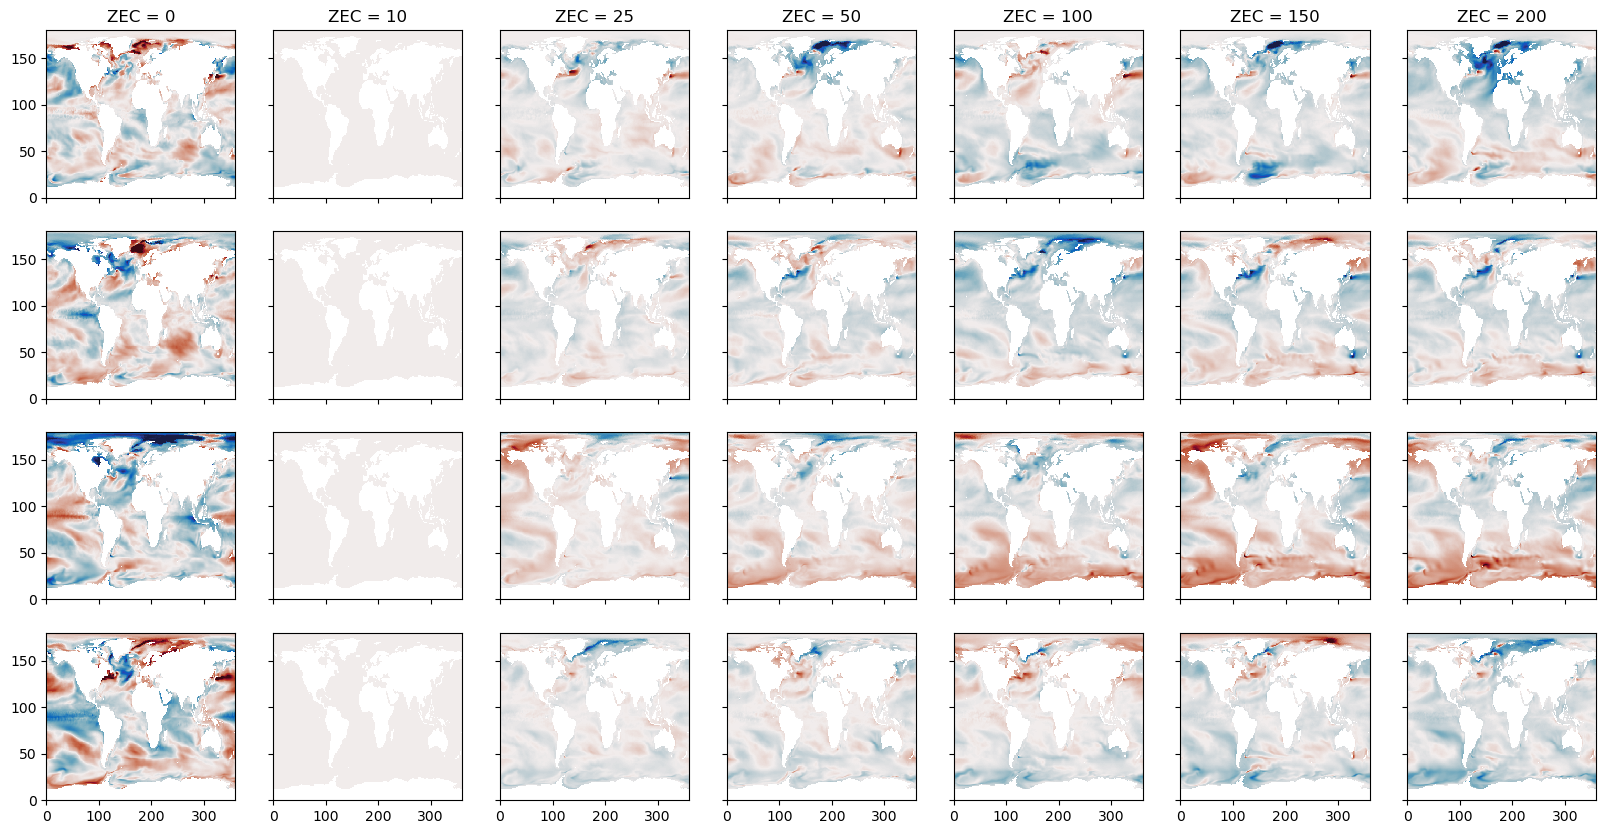

In [17]:
if temporal_stat == 'linear_trend':
    ZECs = ds.ZEC.values
    runs = ds.run
    fig, ax = plt.subplots(4,7,figsize=(20,10),sharex=True,sharey=True)
    for rdx,run in enumerate(ds.run.values):
        for cdx,ZEC in enumerate(ZECs):
            pc = ax[rdx,cdx].pcolormesh((ds[run].sel(ZEC=ZEC)*ZEC),vmin=vmin_trend,vmax=vmax_trend,cmap='cmo.balance')
            if rdx == 0:
                ax[rdx,cdx].set_title(f'ZEC = {ZEC}')
    plt.show()

elif temporal_stat == 'mean':
    fig, ax = plt.subplots(4,7,figsize=(20,10),sharex=True,sharey=True)
    for rdx,run in enumerate(ds.run.values):
        for cdx,ZEC in enumerate(ZECs):
            pc = ax[rdx,cdx].pcolormesh((ds[run].sel(ZEC=ZEC))-ds[run].sel(ZEC=10),vmin=vmin_mean,vmax=vmax_mean,cmap='cmo.balance') # 
            if rdx == 0:
                ax[rdx,cdx].set_title(f'ZEC = {ZEC}')
    plt.show()

## Plot the ZEC as time series

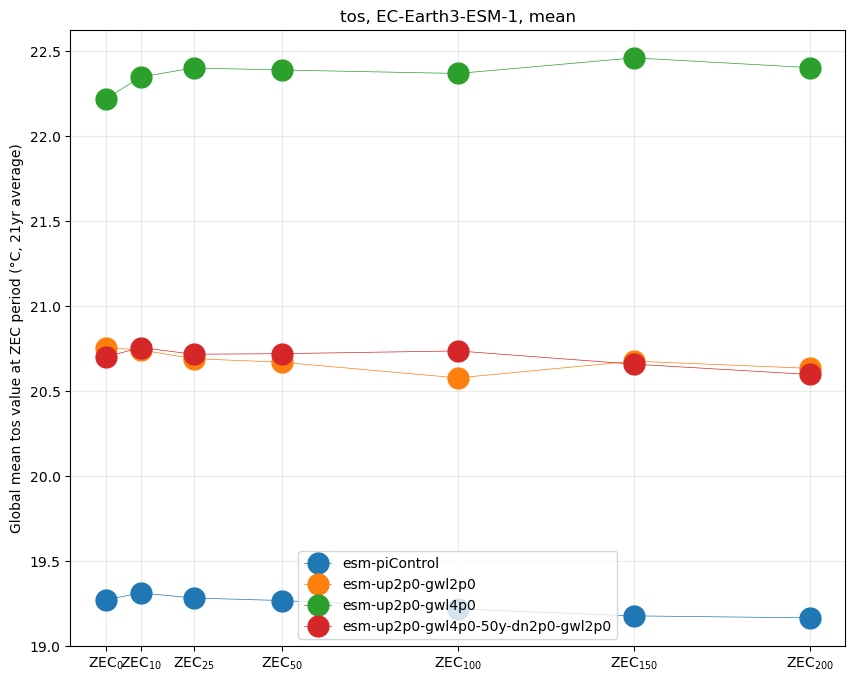

In [18]:
fig, ax = plt.subplots(figsize=(10,8))
for rdx,run in enumerate(ds.run.values):
    if temporal_stat == 'linear_trend':
        ax.plot(ds.ZEC,ds_global_mean[run],label=run,marker='o',linewidth=0.5,markersize=15) # *ds.ZEC
        ax.set_ylabel(f'Global mean linear {varia} trend in {unit_trend} over ZEC period (linear trend)'+'\n cooling                                                        warming') # *ZEC_period
        plt.axhline(0,linestyle='--',color='k')
    elif temporal_stat == 'mean':
        ax.plot(ds.ZEC,ds_global_mean[run],label=run,marker='o',linewidth=0.5,markersize=15) # -ds_global_mean[run].sel(ZEC=10)
        ax.set_ylabel(f'Global mean {varia} value at ZEC period ({unit_mean}, 21yr average)')
plt.grid(alpha=0.25)
ax.set_xticks(ds.ZEC)
ax.set_xticklabels([f'ZEC$_{{{zec_value}}}$' for zec_value in ds.ZEC.values])
plt.legend()
ax.set_title(f'{varia}, {model}, {temporal_stat}')
plt.show()

## Older versions

In [67]:
for varia in varias:
    vert_stat = get_vert_stat(varia)
    for model in models:

        mgrab = MODELgrabber.get_grabber(model)
        #stat = get_stat(varia,model)
        member = mgrab.get_member()
        
        print(f'---{model}---')
        
        temporal_stat_dict = dict()

        ds = xr.Dataset()
        for temporal_stat in temporal_stats:
            for run in run_names:
                statistic_regridded_all = []
                zec_year_bounds = []
                for ZEC in ZECs:
                    print(f'-> calculate time slice statistic(s) for {varia}, {model}, {run}, {ZEC} year ZEC.')
                    print('... identify the time range over which I want to calculate the time slice.')
                    time_slice_start_year, time_slice_end_year = get_time_range_underlying_time_slice(model,run,ZEC,time_window_size)
                    print('... the time range for the time slice statistic is going to be:',time_slice_start_year, time_slice_end_year)
    
                    print('... compute the statisic(s)')
    
                    print(f'    ... computing the {temporal_stat}...')
                    statistic,unit,multiplied_with_area_fraction = calc_time_slice_stat(varia,model,run,time_slice_start_year,time_slice_end_year,temporal_stat=temporal_stat,vert_stat=vert_stat)

                    print(f'    ... regrid the {temporal_stat} to a 1x1 degree grid...')
                    #global_attrs = statistic.attrs()
                    tmp_in = os.path.join("./", "in.nc")
                    tmp_out = os.path.join("./", "out.nc")
                    statistic_regridded = regrid_field(statistic,tmp_in,tmp_out,method='xesmf')
                    statistic_regridded.attrs["unit"] = unit
                    time_slice_start_year_dum = (np.nan if time_slice_start_year is None else time_slice_start_year)
                    time_slice_end_year_dum = (np.nan if time_slice_end_year is None else time_slice_end_year)
                    zec_year_bounds.append([time_slice_start_year_dum,time_slice_end_year_dum])
                    
                    statistic_regridded = statistic_regridded.expand_dims(ZEC=[ZEC])
                    statistic_regridded.attrs["zec_year_bounds"] = zec_year_bounds
                    
                    statistic_regridded_all.append(statistic_regridded)

                # Concatenate along ZEC
                statistic_regridded_all_da = xr.concat(statistic_regridded_all,dim="ZEC")

                ds[run] = statistic_regridded_all_da#.to_dataset(name=run)

            print(f' ')

                
            ## add global attributes to dataset
            ds.attrs = {
                "title": f"Global time slice {temporal_stat}s",
                "model": f"{model}",
                "member": f"{member}",
                "varia": f"{varia}",
                "freq_input": f"{freq_input}",
                "temporal_stat": f"{temporal_stat}",
                "time_window_size": f"{time_window_size}",
                "outroot": f"{outroot}",
                "unit": f"{unit}",
                "multiplied_with_area_fraction": f"{multiplied_with_area_fraction}",
                "author": "E. E. Köhn",
                "created": "2026-05-20",
            }
            ## save the dataset 
            outdir = f"{outroot}/{varia}/{model}/{temporal_stat}"
            os.makedirs(outdir, exist_ok=True)
            if temporal_stat != 'linear_trend':
                filename = f"{varia}_{model}_{temporal_stat}_win{time_window_size}yr.nc"
            else:
                filename = f"{varia}_{model}_{temporal_stat}.nc"
            outfile = f"{outdir}/{filename}" # "_piC" the _piC suffix was added for the ACCESS-ESM1-5 case for separate saving of the netcdf, as the data is distributed between spirit and dkrz 
            ds.to_netcdf(outfile)
        


---IPSL-CM6-ESMCO2---
-> calculate time slice statistic(s) for tas, IPSL-CM6-ESMCO2, esm-piControl, 10 year ZEC.
... identify the time range over which I want to calculate the time slice.
1850
1870
1850
1870
... the time range for the time slice statistic is going to be: 1850 1870
... compute the statisic(s)
    ... computing the mean...
/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Amon/tas/gr/v*/tas*_gr_*.nc
['/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Amon/tas/gr/v20260318/tas_Amon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gr_180001-184912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Amon/tas/gr/v20260318/tas_Amon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gr_185001-194912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Amon/tas/gr/v20260318/tas_Amon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gr_195001-204912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Amon/tas/gr/v20260318/tas_Amon_IPSL-CM6-ESMCO2_esm-

ValueError: multi-dimensional array attributes not supported

In [66]:
ds

<xarray.Dataset>
Dimensions:                            (ZEC: 6, lat: 180, lon: 360)
Coordinates:
  * ZEC                                (ZEC) int64 10 25 50 100 150 200
    height                             float64 2.0
  * lat                                (lat) float64 -89.5 -88.5 ... 88.5 89.5
  * lon                                (lon) float64 -179.5 -178.5 ... 179.5
Data variables:
    esm-piControl                      (ZEC, lat, lon) float32 dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    esm-up2p0-gwl2p0                   (ZEC, lat, lon) float32 dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    esm-up2p0-gwl4p0                   (ZEC, lat, lon) float32 dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0  (ZEC, lat, lon) float32 dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
Attributes:
    title:                          Global time slice means
    model:                          IPSL-CM6-ESMCO2
    member:                         r1i2p3f1
    varia:                          tas
    freq_input:                     monthly
    temporal_stat:                  mean
    time_window_size:               21
    outroot:                        ./../01_postprocessed_data/global_time_sl...
    unit:                           K
    multiplied_with_area_fraction:  False
    author:                         E. E. Köhn
    created:                        2026-05-20

## Some manual merging of files for the case that different parts of the final file were computed on different clusters (as the case for ACCESS, piC on spirit, rest on Levante)

In [9]:
outroot

'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/'

In [12]:
## Some merging of the files now

varias = ['tas','tos','nbp','fgco2','npp','intpp','cLand','cVeg']#,'cSoil']
for varia in varias:
    
    outdir = f"{outroot}/{varia}/{model}/{temporal_stat}"

    outfile = (
        f"{outdir}/{varia}_{model}_{temporal_stat}"
        f"_win{time_window_size}yr.nc"
    )

    outfile_piC = (
        f"{outdir}/{varia}_{model}_{temporal_stat}"
        f"_win{time_window_size}yr_piC.nc"
    )

    # skip if piControl file does not exist
    if not os.path.exists(outfile_piC):
        continue

    if not os.path.exists(outfile):
        continue

    # open datasets
    ds_main = xr.open_dataset(outfile)
    ds_pic = xr.open_dataset(outfile_piC)

    # merge datasets
    #ds_merged = xr.merge([ds_main, ds_pic])
    for varname in ds_pic.data_vars:
        ds_main[varname] = ds_pic[varname]

    # encoding
    valid_keys = {
        "_FillValue",
        "dtype",
        "zlib",
        "complevel",
        "shuffle",
        "fletcher32",
        "contiguous",
        "chunksizes",
        "endian",
        "least_significant_digit",
    }
    
    encoding = {}
    
    for ds in [ds_main, ds_pic]:
        for var in ds.data_vars:
            enc = ds[var].encoding
    
            # keep only supported encoding keys
            encoding[var] = {
                k: v for k, v in enc.items()
                if k in valid_keys
            }

    # temporary output file
    tmpfile = outfile.replace(".nc", "_tmp.nc")

    # save merged dataset
    ds_main.to_netcdf(tmpfile, encoding=encoding)

    # close datasets before overwriting/removing
    ds_main.close()
    ds_pic.close()

    # replace original file
    os.replace(tmpfile, outfile)

    # remove piControl file
    os.remove(outfile_piC)

    print(f"Merged and removed: {outfile_piC}")

Merged and removed: ./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC//tos/ACCESS-ESM1-5/mean/tos_ACCESS-ESM1-5_mean_win21yr_piC.nc
Merged and removed: ./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC//fgco2/ACCESS-ESM1-5/mean/fgco2_ACCESS-ESM1-5_mean_win21yr_piC.nc
Merged and removed: ./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC//npp/ACCESS-ESM1-5/mean/npp_ACCESS-ESM1-5_mean_win21yr_piC.nc
Merged and removed: ./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC//intpp/ACCESS-ESM1-5/mean/intpp_ACCESS-ESM1-5_mean_win21yr_piC.nc
Merged and removed: ./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC//cVeg/ACCESS-ESM1-5/mean/cVeg_ACCESS-ESM1-5_mean_win21yr_piC.nc


In [11]:
xr.open_dataset('/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps_ZEC/tas/ACCESS-ESM1-5/mean/tas_ACCESS-ESM1-5_mean_win21yr.nc')

<xarray.Dataset>
Dimensions:                            (ZEC: 7, lat: 180, lon: 360, run: 3)
Coordinates:
  * ZEC                                (ZEC) int64 0 10 25 50 100 150 200
  * lat                                (lat) float64 -89.5 -88.5 ... 88.5 89.5
  * lon                                (lon) float64 -179.5 -178.5 ... 179.5
  * run                                (run) <U13 'esm-up2p0-gwl' ... 'esm-up...
    height                             float64 ...
Data variables:
    esm-up2p0-gwl2p0                   (ZEC, lat, lon) float32 ...
    esm-up2p0-gwl4p0                   (ZEC, lat, lon) float32 ...
    esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0  (ZEC, lat, lon) float32 ...
    ZEC_start_year                     (run, ZEC) int64 ...
    ZEC_end_year                       (run, ZEC) int64 ...
    esm-piControl                      (ZEC, lat, lon) float32 ...
Attributes:
    title:                          Global time slice means
    model:                          ACCESS-ESM1-5
    member:                         r1i1p1f1
    varia:                          tas
    freq_input:                     monthly
    temporal_stat:                  mean
    time_window_size:               21
    outroot:                        ./../01_postprocessed_data/global_time_sl...
    unit:                           K
    multiplied_with_area_fraction:  False
    author:                         E. E. Köhn
    created:                        2026-05-20